## 1. Setup & Data Loading

In [3]:
# Install required packages if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn torch

In [4]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Sklearn for preprocessing and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

# PyTorch for neural network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Using device: cuda


In [ ]:
# Load data (path comes from kagglehub.competition_download)
DATA_PATH = Path(path)

train_df = pd.read_csv(DATA_PATH / 'train.csv')
test_df = pd.read_csv(DATA_PATH / 'test.csv')
sample_submission = pd.read_csv(DATA_PATH / 'sample_submission.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

Train shape: (8693, 14)
Test shape: (4277, 13)
Sample submission shape: (4277, 2)


In [6]:
# Quick peek at the data
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
# Data types and info
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [8]:
# Statistical summary
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


---
## 2. Exploratory Data Analysis (EDA)

Let's understand our data before building the model.

### 2.1 Target Distribution

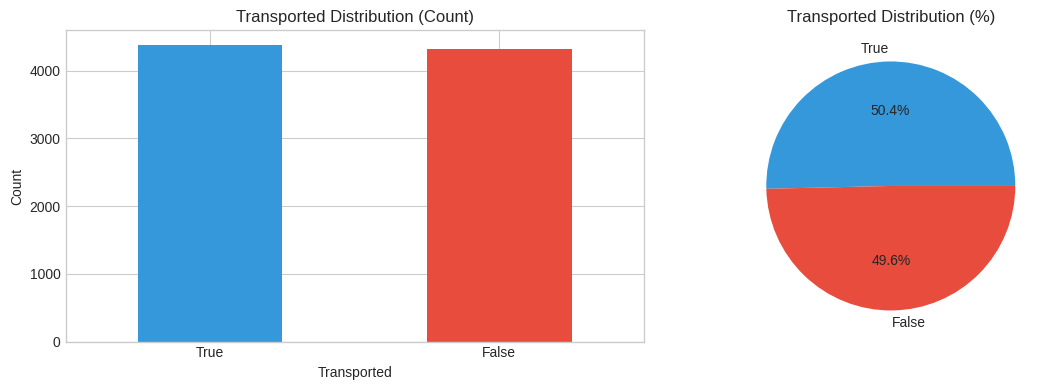


Target balance: {True: 0.5036236051995858, False: 0.4963763948004141}
✓ Classes are fairly balanced - no need for oversampling/undersampling


In [9]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
train_df['Transported'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Transported Distribution (Count)')
axes[0].set_xlabel('Transported')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Percentage
train_df['Transported'].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
                                                          autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
axes[1].set_title('Transported Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nTarget balance: {train_df['Transported'].value_counts(normalize=True).to_dict()}")
print("✓ Classes are fairly balanced - no need for oversampling/undersampling")

### 2.2 Missing Values Analysis

In [10]:
# Missing values in train and test
def missing_values_table(df, name):
    missing = df.isnull().sum()
    missing_pct = 100 * df.isnull().sum() / len(df)
    table = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_pct})
    table = table[table['Missing Values'] > 0].sort_values('Missing Values', ascending=False)
    print(f"\n{name} - Missing Values:")
    print(f"Total features with missing values: {len(table)}")
    return table

train_missing = missing_values_table(train_df, 'Train')
display(train_missing)

test_missing = missing_values_table(test_df, 'Test')
display(test_missing)


Train - Missing Values:
Total features with missing values: 12


,Missing Values,Percentage
CryoSleep,217,2.496261
ShoppingMall,208,2.392730
VIP,203,2.335212
HomePlanet,201,2.312205
Name,200,2.300702
Cabin,199,2.289198
VRDeck,188,2.162660
FoodCourt,183,2.105142
Spa,183,2.105142
Destination,182,2.093639



Test - Missing Values:
Total features with missing values: 12


,Missing Values,Percentage
FoodCourt,106,2.478373
Spa,101,2.361468
Cabin,100,2.338087
ShoppingMall,98,2.291326
Name,94,2.197802
VIP,93,2.174421
CryoSleep,93,2.174421
Destination,92,2.151040
Age,91,2.127660
HomePlanet,87,2.034136


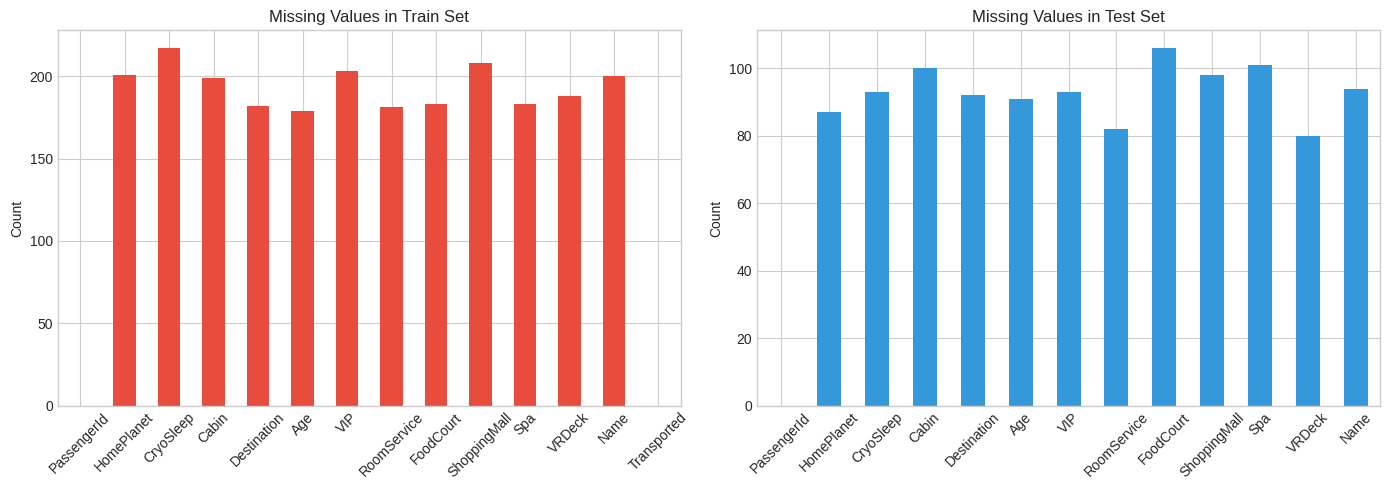

In [11]:
# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train missing
train_df.isnull().sum().plot(kind='bar', ax=axes[0], color='#e74c3c')
axes[0].set_title('Missing Values in Train Set')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Test missing
test_df.isnull().sum().plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Missing Values in Test Set')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.3 Numerical Features Analysis

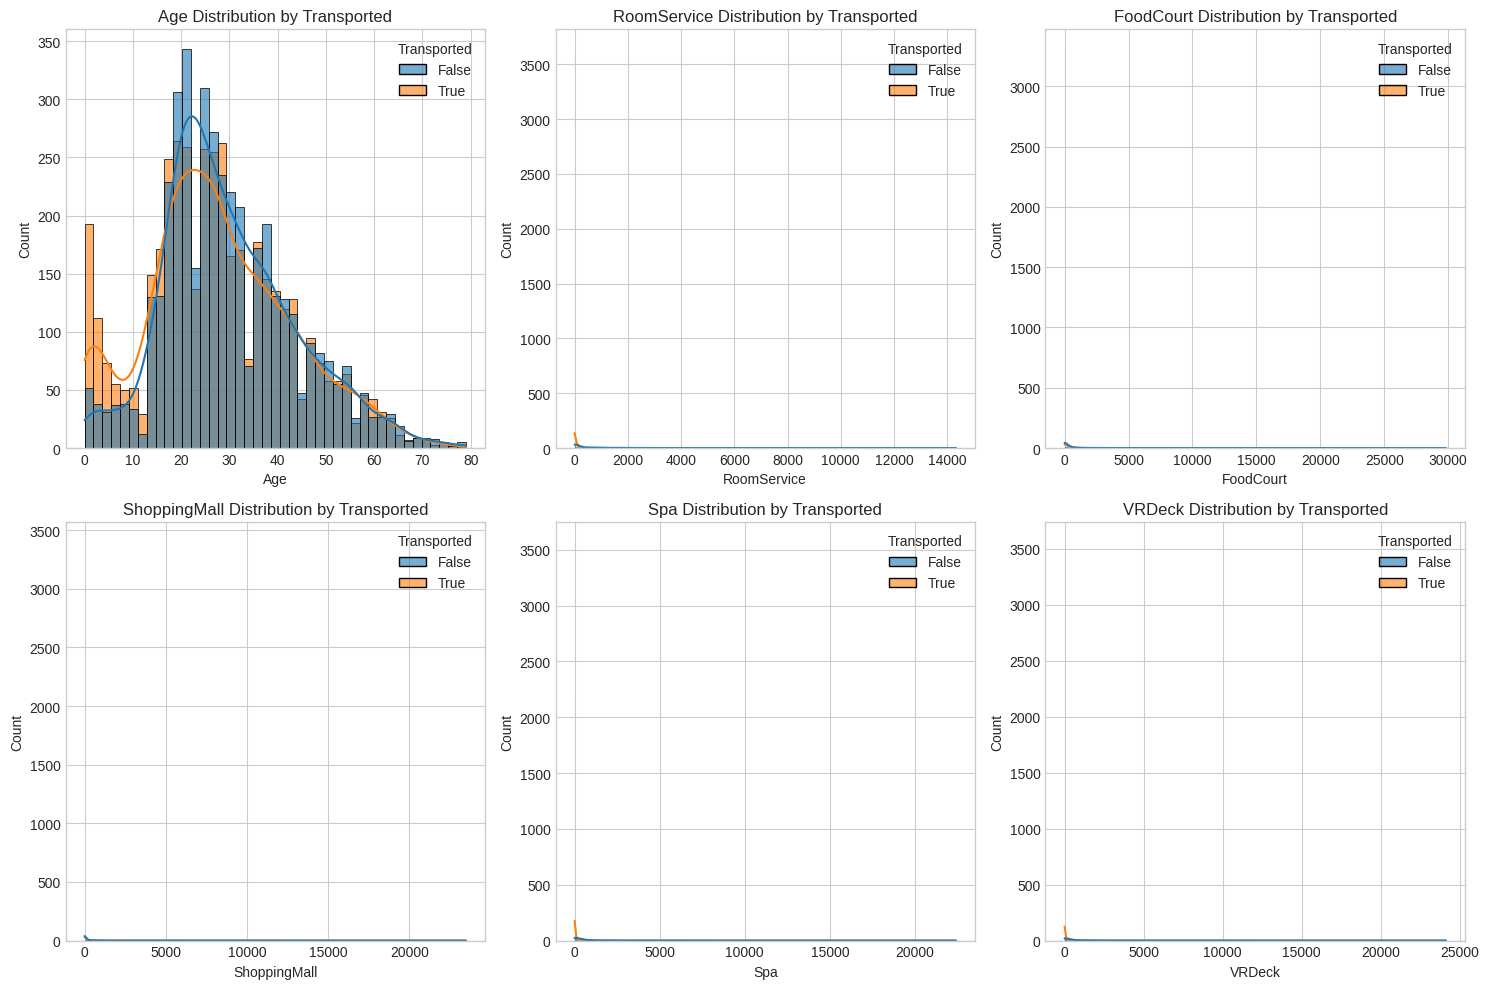

In [12]:
# Numerical columns
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Histogram with KDE
    sns.histplot(data=train_df, x=col, hue='Transported', kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{col} Distribution by Transported')

plt.tight_layout()
plt.show()

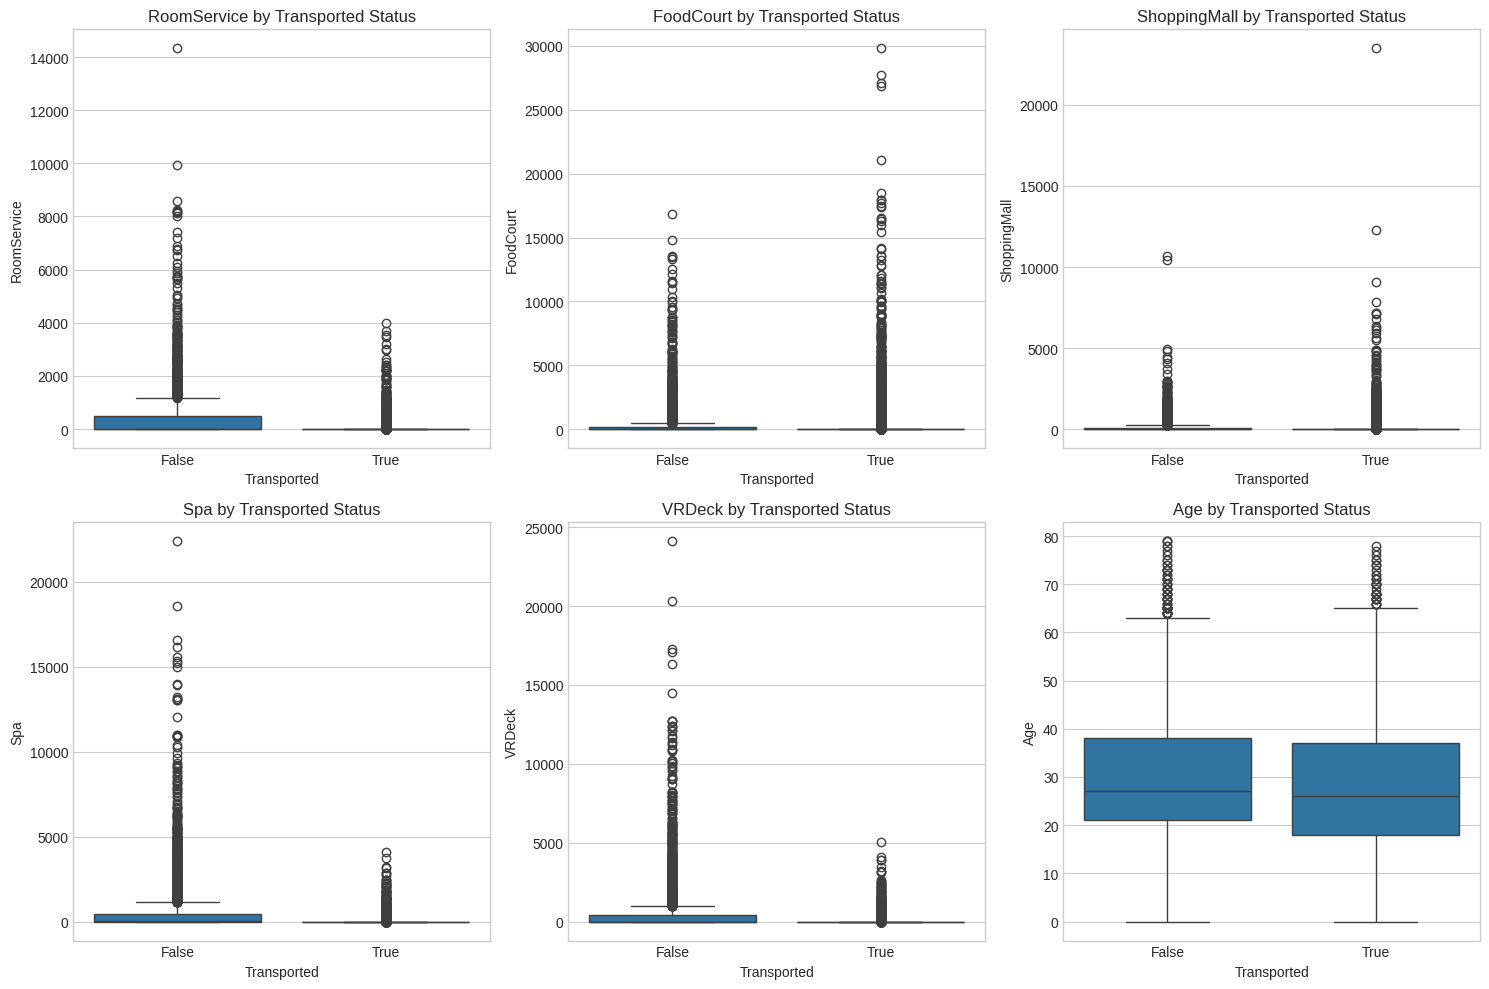


📊 Key Observation: Spending patterns differ significantly by transport status!
   People who were NOT transported tend to have higher spending.


In [13]:
# Spending columns analysis
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Log transform for better visualization (spending is heavily skewed)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    # Box plot by transported status
    sns.boxplot(data=train_df, x='Transported', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Transported Status')

# Age boxplot
sns.boxplot(data=train_df, x='Transported', y='Age', ax=axes[5])
axes[5].set_title('Age by Transported Status')

plt.tight_layout()
plt.show()

# Key insight
print("\n📊 Key Observation: Spending patterns differ significantly by transport status!")
print("   People who were NOT transported tend to have higher spending.")

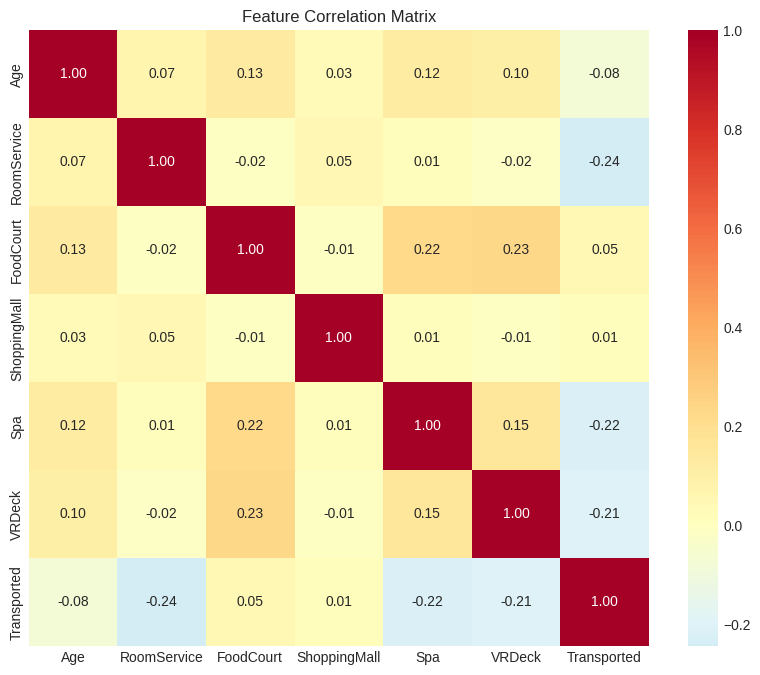


📊 Correlation with Transported:
Transported     1.000000
FoodCourt       0.046566
ShoppingMall    0.010141
Age            -0.075026
VRDeck         -0.207075
Spa            -0.221131
RoomService    -0.244611
Name: Transported, dtype: float64


In [14]:
# Correlation matrix
plt.figure(figsize=(10, 8))

# Create correlation matrix including target
corr_df = train_df[numerical_cols + ['Transported']].copy()
corr_df['Transported'] = corr_df['Transported'].astype(int)

correlation = corr_df.corr()
sns.heatmap(correlation, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

print("\n📊 Correlation with Transported:")
print(correlation['Transported'].sort_values(ascending=False))

### 2.4 Categorical Features Analysis

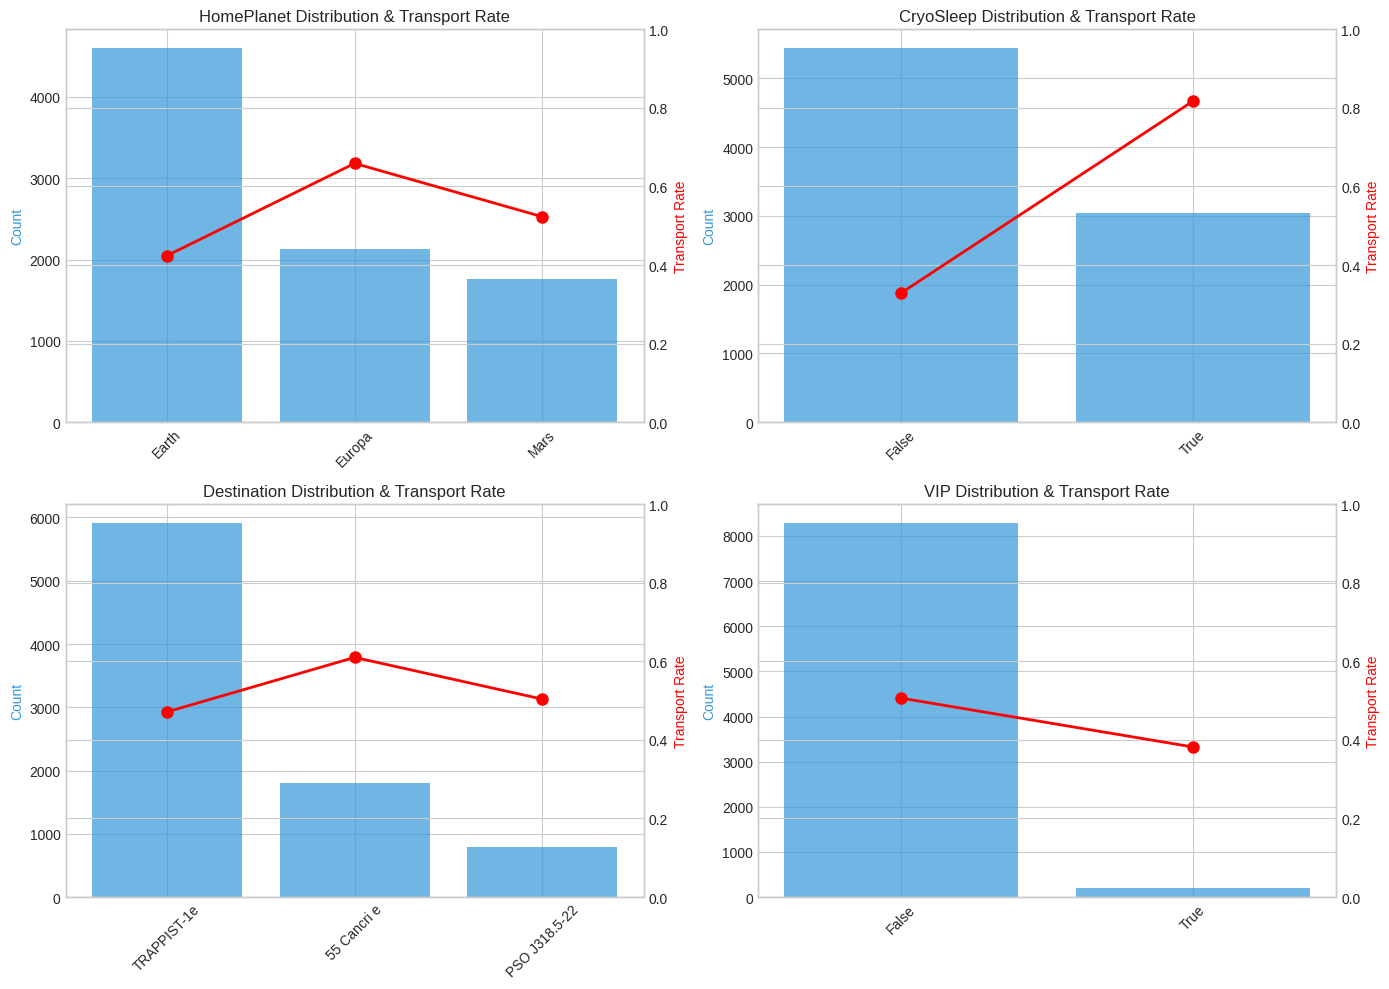

In [15]:
# Categorical columns
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate transport rate by category
    transport_rate = train_df.groupby(col)['Transported'].mean().sort_values(ascending=False)

    # Count plot with transport rate overlay
    ax1 = axes[i]
    counts = train_df[col].value_counts()
    bars = ax1.bar(counts.index.astype(str), counts.values, color='#3498db', alpha=0.7)
    ax1.set_ylabel('Count', color='#3498db')
    ax1.set_title(f'{col} Distribution & Transport Rate')
    ax1.tick_params(axis='x', rotation=45)

    # Overlay transport rate line
    ax2 = ax1.twinx()
    transport_rate_reindexed = transport_rate.reindex(counts.index)
    ax2.plot(transport_rate_reindexed.index.astype(str), transport_rate_reindexed.values,
             'ro-', linewidth=2, markersize=8)
    ax2.set_ylabel('Transport Rate', color='red')
    ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [16]:
# CryoSleep is a strong predictor - let's investigate
print("\n🔍 CryoSleep Analysis:")
cryo_analysis = train_df.groupby('CryoSleep').agg({
    'Transported': ['count', 'mean'],
    'RoomService': 'mean',
    'FoodCourt': 'mean',
    'ShoppingMall': 'mean',
    'Spa': 'mean',
    'VRDeck': 'mean'
}).round(2)
print(cryo_analysis)

print("\n💡 INSIGHT: CryoSleep passengers have ZERO spending (they're in suspended animation!)")
print("   And they have a much higher transport rate (~81% vs ~34%)")


🔍 CryoSleep Analysis:
          Transported       RoomService FoodCourt ShoppingMall     Spa  VRDeck
                count  mean        mean      mean         mean    mean    mean
CryoSleep                                                                     
False            5439  0.33      350.15     713.0       270.59  486.09  475.72
True             3037  0.82        0.00       0.0         0.00    0.00    0.00

💡 INSIGHT: CryoSleep passengers have ZERO spending (they're in suspended animation!)
   And they have a much higher transport rate (~81% vs ~34%)


### 2.5 PassengerId & Group Analysis


👥 Group Size Distribution:
GroupSize
1    4805
2    1682
3    1020
4     412
5     265
6     174
7     231
8     104
Name: count, dtype: int64


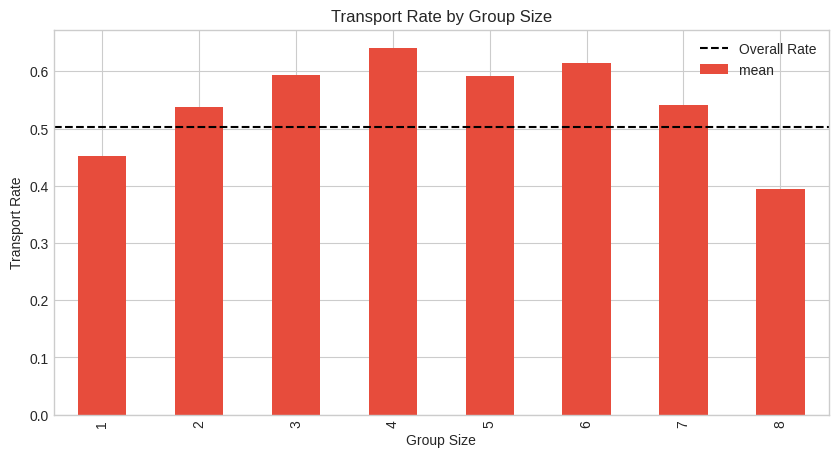

In [17]:
# Extract group info from PassengerId
train_df['Group'] = train_df['PassengerId'].apply(lambda x: x.split('_')[0])
train_df['GroupNum'] = train_df['PassengerId'].apply(lambda x: int(x.split('_')[1]))

# Group size
group_sizes = train_df.groupby('Group').size().reset_index(name='GroupSize')
train_df = train_df.merge(group_sizes, on='Group', how='left')

# Analyze group size impact
print("\n👥 Group Size Distribution:")
print(train_df['GroupSize'].value_counts().sort_index())

# Transport rate by group size
plt.figure(figsize=(10, 5))
group_transport = train_df.groupby('GroupSize')['Transported'].agg(['mean', 'count'])
group_transport['mean'].plot(kind='bar', color='#e74c3c')
plt.title('Transport Rate by Group Size')
plt.xlabel('Group Size')
plt.ylabel('Transport Rate')
plt.axhline(y=train_df['Transported'].mean(), color='black', linestyle='--', label='Overall Rate')
plt.legend()
plt.show()

# Clean up temporary columns (will recreate in feature engineering)
train_df = train_df.drop(['Group', 'GroupNum', 'GroupSize'], axis=1)

### 2.6 Cabin Analysis

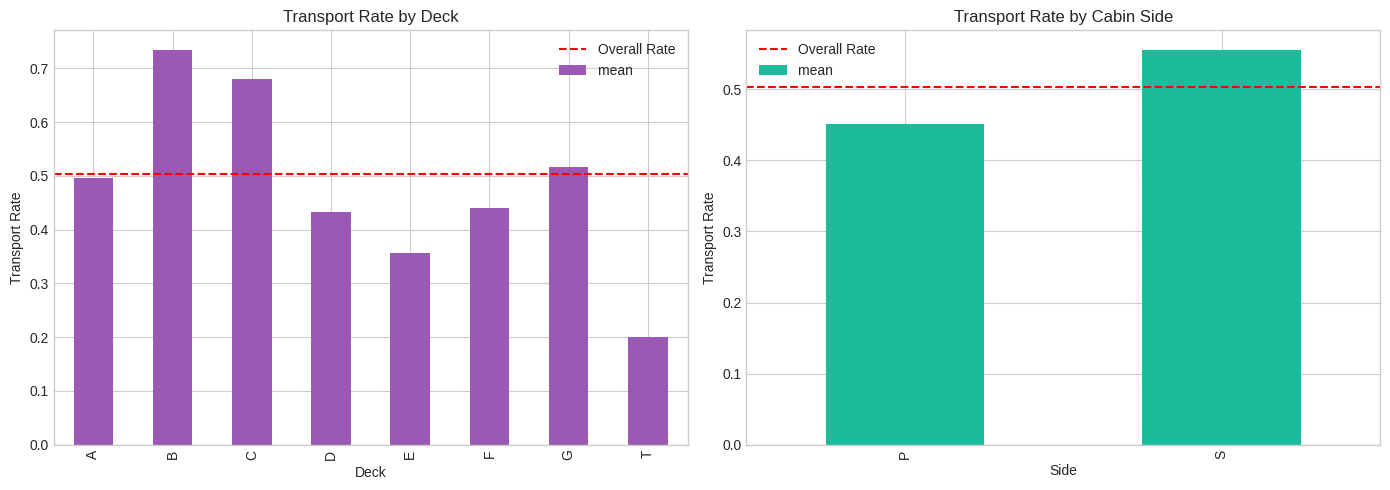


💡 INSIGHT: Different decks have different transport rates!
   Deck B and C have higher transport rates.


In [18]:
# Parse Cabin: deck/num/side
def parse_cabin(cabin):
    if pd.isna(cabin):
        return pd.Series([np.nan, np.nan, np.nan])
    parts = cabin.split('/')
    return pd.Series([parts[0], int(parts[1]), parts[2]])

cabin_parsed = train_df['Cabin'].apply(parse_cabin)
cabin_parsed.columns = ['Deck', 'CabinNum', 'Side']

# Analyze deck
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transport rate by Deck
deck_transport = pd.concat([cabin_parsed['Deck'], train_df['Transported']], axis=1)
deck_rate = deck_transport.groupby('Deck')['Transported'].agg(['mean', 'count'])
deck_rate['mean'].plot(kind='bar', ax=axes[0], color='#9b59b6')
axes[0].set_title('Transport Rate by Deck')
axes[0].set_ylabel('Transport Rate')
axes[0].axhline(y=train_df['Transported'].mean(), color='red', linestyle='--', label='Overall Rate')
axes[0].legend()

# Transport rate by Side (Port vs Starboard)
side_transport = pd.concat([cabin_parsed['Side'], train_df['Transported']], axis=1)
side_rate = side_transport.groupby('Side')['Transported'].agg(['mean', 'count'])
side_rate['mean'].plot(kind='bar', ax=axes[1], color='#1abc9c')
axes[1].set_title('Transport Rate by Cabin Side')
axes[1].set_ylabel('Transport Rate')
axes[1].axhline(y=train_df['Transported'].mean(), color='red', linestyle='--', label='Overall Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: Different decks have different transport rates!")
print("   Deck B and C have higher transport rates.")

### 2.7 EDA Summary

**Key Findings:**
1. ✅ Target is balanced (~50/50) - no need for resampling
2. 🔑 **CryoSleep** is the strongest predictor - 81% of cryo passengers were transported
3. 💰 **Spending features** are important - transported passengers tend to spend less
4. 🚪 **Cabin Deck** matters - Decks B and C have higher transport rates
5. 👥 **Group size** affects transport rate - solo travelers differ from groups
6. ⚠️ Missing values present in multiple columns - need careful imputation

---

## 3. Data Preprocessing

In [ ]:
# Reload fresh data for preprocessing
train_df = pd.read_csv(DATA_PATH / 'train.csv')
test_df = pd.read_csv(DATA_PATH / 'test.csv')

# Store PassengerId for submission
train_ids = train_df['PassengerId'].copy()
test_ids = test_df['PassengerId'].copy()

# Store target
target = train_df['Transported'].copy()

# Combine for consistent preprocessing
train_df['is_train'] = True
test_df['is_train'] = False
test_df['Transported'] = np.nan  # Placeholder

combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
print(f"Combined shape: {combined_df.shape}")

Combined shape: (12970, 15)


### 3.1 Feature Engineering

In [20]:
# 1. Extract Group features from PassengerId
combined_df['Group'] = combined_df['PassengerId'].apply(lambda x: x.split('_')[0])
combined_df['GroupNum'] = combined_df['PassengerId'].apply(lambda x: int(x.split('_')[1]))

# Group size
group_sizes = combined_df.groupby('Group').size().reset_index(name='GroupSize')
combined_df = combined_df.merge(group_sizes, on='Group', how='left')

# Is alone
combined_df['IsAlone'] = (combined_df['GroupSize'] == 1).astype(int)

print("✓ Created: Group, GroupNum, GroupSize, IsAlone")

✓ Created: Group, GroupNum, GroupSize, IsAlone


In [21]:
# 2. Parse Cabin into Deck, CabinNum, Side
def parse_cabin(cabin):
    if pd.isna(cabin):
        return pd.Series([np.nan, np.nan, np.nan])
    parts = cabin.split('/')
    return pd.Series([parts[0], int(parts[1]), parts[2]])

cabin_features = combined_df['Cabin'].apply(parse_cabin)
cabin_features.columns = ['Deck', 'CabinNum', 'Side']
combined_df = pd.concat([combined_df, cabin_features], axis=1)

print("✓ Created: Deck, CabinNum, Side")

✓ Created: Deck, CabinNum, Side


In [22]:
# 3. Spending features
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Total spending (handle NaN)
combined_df['TotalSpending'] = combined_df[spending_cols].sum(axis=1, skipna=True)

# Number of spending categories used
combined_df['SpendingCategories'] = (combined_df[spending_cols] > 0).sum(axis=1)

# Binary: has any spending
combined_df['HasSpending'] = (combined_df['TotalSpending'] > 0).astype(int)

# Log transform for spending (add 1 to handle zeros)
for col in spending_cols:
    combined_df[f'{col}_log'] = np.log1p(combined_df[col])

combined_df['TotalSpending_log'] = np.log1p(combined_df['TotalSpending'])

print("✓ Created: TotalSpending, SpendingCategories, HasSpending, log-transformed spending")

✓ Created: TotalSpending, SpendingCategories, HasSpending, log-transformed spending


In [23]:
# 4. Age features
combined_df['IsChild'] = (combined_df['Age'] < 18).astype(float)
combined_df['IsElderly'] = (combined_df['Age'] > 60).astype(float)

# Age groups
combined_df['AgeGroup'] = pd.cut(combined_df['Age'],
                                  bins=[0, 12, 18, 30, 50, 100],
                                  labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

print("✓ Created: IsChild, IsElderly, AgeGroup")

✓ Created: IsChild, IsElderly, AgeGroup


In [24]:
# 5. Extract family name from Name
combined_df['FamilyName'] = combined_df['Name'].apply(
    lambda x: x.split()[-1] if pd.notna(x) else np.nan
)

# Family size based on name
family_sizes = combined_df.groupby('FamilyName').size().reset_index(name='FamilySize')
combined_df = combined_df.merge(family_sizes, on='FamilyName', how='left')
combined_df['FamilySize'] = combined_df['FamilySize'].fillna(1)

print("✓ Created: FamilyName, FamilySize")

✓ Created: FamilyName, FamilySize


### 3.2 Handle Missing Values

In [25]:
# Check missing values again
print("Missing values before imputation:")
print(combined_df.isnull().sum()[combined_df.isnull().sum() > 0])

Missing values before imputation:
HomePlanet           288
CryoSleep            310
Cabin                299
Destination          274
Age                  270
VIP                  296
RoomService          263
FoodCourt            289
ShoppingMall         306
Spa                  284
VRDeck               268
Name                 294
Transported         4277
Deck                 299
CabinNum             299
Side                 299
RoomService_log      263
FoodCourt_log        289
ShoppingMall_log     306
Spa_log              284
VRDeck_log           268
AgeGroup             530
FamilyName           294
dtype: int64


In [26]:
# Strategy for imputation:
# - CryoSleep: derived from spending (if spending > 0, CryoSleep = False)
# - Spending cols: if CryoSleep = True, impute with 0; else median
# - Categorical: mode imputation
# - Age: median imputation

# 1. Smart imputation for CryoSleep based on spending
has_spending_mask = combined_df['TotalSpending'] > 0
combined_df.loc[has_spending_mask & combined_df['CryoSleep'].isna(), 'CryoSleep'] = False

# Fill remaining CryoSleep with mode
combined_df['CryoSleep'] = combined_df['CryoSleep'].fillna(combined_df['CryoSleep'].mode()[0])

# 2. Smart imputation for spending based on CryoSleep
for col in spending_cols:
    # If CryoSleep = True, spending should be 0
    combined_df.loc[combined_df['CryoSleep'] == True, col] = combined_df.loc[
        combined_df['CryoSleep'] == True, col].fillna(0)
    # Otherwise, fill with median
    median_val = combined_df.loc[combined_df['CryoSleep'] == False, col].median()
    combined_df[col] = combined_df[col].fillna(median_val)

print("✓ Imputed CryoSleep and spending columns")

✓ Imputed CryoSleep and spending columns


In [27]:
# 3. Impute other numerical columns with median
combined_df['Age'] = combined_df['Age'].fillna(combined_df['Age'].median())
combined_df['CabinNum'] = combined_df['CabinNum'].fillna(combined_df['CabinNum'].median())

# 4. Impute categorical columns with mode
categorical_to_impute = ['HomePlanet', 'Destination', 'VIP', 'Deck', 'Side']
for col in categorical_to_impute:
    combined_df[col] = combined_df[col].fillna(combined_df[col].mode()[0])

# Recalculate derived features after imputation
combined_df['TotalSpending'] = combined_df[spending_cols].sum(axis=1)
combined_df['SpendingCategories'] = (combined_df[spending_cols] > 0).sum(axis=1)
combined_df['HasSpending'] = (combined_df['TotalSpending'] > 0).astype(int)
combined_df['TotalSpending_log'] = np.log1p(combined_df['TotalSpending'])

for col in spending_cols:
    combined_df[f'{col}_log'] = np.log1p(combined_df[col])

# Recalculate age features
combined_df['IsChild'] = (combined_df['Age'] < 18).astype(int)
combined_df['IsElderly'] = (combined_df['Age'] > 60).astype(int)
combined_df['AgeGroup'] = pd.cut(combined_df['Age'],
                                  bins=[0, 12, 18, 30, 50, 100],
                                  labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

print("✓ Imputed Age, CabinNum, and categorical columns")

✓ Imputed Age, CabinNum, and categorical columns


In [28]:
# Verify no missing values in key columns
feature_cols = (['Age', 'CryoSleep', 'VIP', 'HomePlanet', 'Destination', 'Deck', 'Side'] +
                spending_cols +
                ['TotalSpending', 'GroupSize', 'IsAlone', 'CabinNum'])
print("Missing values after imputation:")
print(combined_df[feature_cols].isnull().sum())

Missing values after imputation:
Age              0
CryoSleep        0
VIP              0
HomePlanet       0
Destination      0
Deck             0
Side             0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
TotalSpending    0
GroupSize        0
IsAlone          0
CabinNum         0
dtype: int64


### 3.3 Encode Categorical Features

In [ ]:
# Convert boolean columns to int
combined_df['CryoSleep'] = combined_df['CryoSleep'].astype(int)
combined_df['VIP'] = combined_df['VIP'].astype(int)

# One-hot encode categorical columns
categorical_cols_to_encode = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup']

# drop_first=True to avoid multicollinearity
combined_df = pd.get_dummies(combined_df, columns=categorical_cols_to_encode, drop_first=True)

print(f"\nShape after encoding: {combined_df.shape}")
print("✓ Encoded categorical columns (drop_first=True)")

KeyError: "None of [Index(['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup'], dtype='object')] are in the [columns]"

### 3.4 Select Final Features

In [ ]:
# Drop columns not needed + redundant features to reduce overfitting
drop_cols = ['PassengerId', 'Cabin', 'Name', 'Group', 'FamilyName',
             'Transported', 'is_train', 'GroupNum',
             'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',  # redundant with log versions
             'CabinNum']  # noisy

feature_columns = [col for col in combined_df.columns if col not in drop_cols]
print(f"Number of features: {len(feature_columns)}")
print(f"\nFeatures: {feature_columns}")

Number of features: 44

Features: ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'IsAlone', 'CabinNum', 'TotalSpending', 'SpendingCategories', 'HasSpending', 'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log', 'TotalSpending_log', 'IsChild', 'IsElderly', 'FamilySize', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_P', 'Side_S', 'AgeGroup_Child', 'AgeGroup_Teen', 'AgeGroup_YoungAdult', 'AgeGroup_Adult', 'AgeGroup_Senior']


In [67]:
# Split back into train and test
train_processed = combined_df[combined_df['is_train'] == True].copy()
test_processed = combined_df[combined_df['is_train'] == False].copy()

X = train_processed[feature_columns].values
y = target.values.astype(int)
X_test_final = test_processed[feature_columns].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test_final.shape}")

X shape: (8693, 44)
y shape: (8693,)
X_test shape: (4277, 44)


### 3.5 Scale Features

In [68]:
# Scale features (important for neural networks!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

print("✓ Features scaled with StandardScaler")
print(f"Feature means (should be ~0): {X_scaled.mean(axis=0)[:5]}")
print(f"Feature stds (should be ~1): {X_scaled.std(axis=0)[:5]}")

✓ Features scaled with StandardScaler
Feature means (should be ~0): [-9.68587532e-17 -2.12517096e-17  5.12901837e-17 -2.02299928e-17
 -1.47127220e-17]
Feature stds (should be ~1): [1. 1. 1. 1. 1.]


### 3.6 Train/Validation Split

In [69]:
# Stratified train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nTarget distribution:")
print(f"  Train: {np.mean(y_train):.3f}")
print(f"  Val: {np.mean(y_val):.3f}")
print("✓ Stratified split preserves target distribution")

Training set: 6954 samples
Validation set: 1739 samples

Target distribution:
  Train: 0.504
  Val: 0.504
✓ Stratified split preserves target distribution


---
## 4. Neural Network Model

Now let's build our PyTorch neural network!

In [ ]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

# Larger batch = smoother gradients = less overfitting
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")

Number of batches in train_loader: 109
Number of batches in val_loader: 28


### 4.1 Define Neural Network Architecture

In [ ]:
class SpaceshipNN(nn.Module):
    """Compact NN to avoid overfitting on small dataset."""
    def __init__(self, input_dim, hidden_dims=[64, 32], dropout_rate=0.5):
        super(SpaceshipNN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Small model: [64, 32] with 50% dropout
input_dim = X_train.shape[1]
model = SpaceshipNN(input_dim=input_dim, hidden_dims=[64, 32], dropout_rate=0.5).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SpaceshipNN(
  (network): Sequential(
    (0): Linear(in_features=44, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters: 53,633


### 4.2 Define Loss, Optimizer, and Training Loop

In [ ]:
# Lower LR + strong L2 regularization
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-3)

# Reduce LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        predictions = (outputs > 0.5).float()
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total

def evaluate(model, val_loader, criterion):
    """Evaluate on validation set."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            predictions = (outputs > 0.5).float()
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total

### 4.3 Train the Model

In [74]:
# Training configuration
NUM_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 15

# Track metrics
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Early stopping variables
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\n✓ Training complete! Best validation loss: {best_val_loss:.4f}")

Starting training...

Epoch   1/100 | Train Loss: 0.4943 | Train Acc: 0.7645 | Val Loss: 0.4118 | Val Acc: 0.8045
Epoch  10/100 | Train Loss: 0.4005 | Train Acc: 0.8133 | Val Loss: 0.3899 | Val Acc: 0.8068
Epoch  20/100 | Train Loss: 0.3757 | Train Acc: 0.8227 | Val Loss: 0.3948 | Val Acc: 0.8074

⚠️ Early stopping triggered at epoch 23

✓ Training complete! Best validation loss: 0.3877


### 4.4 Plot Training History

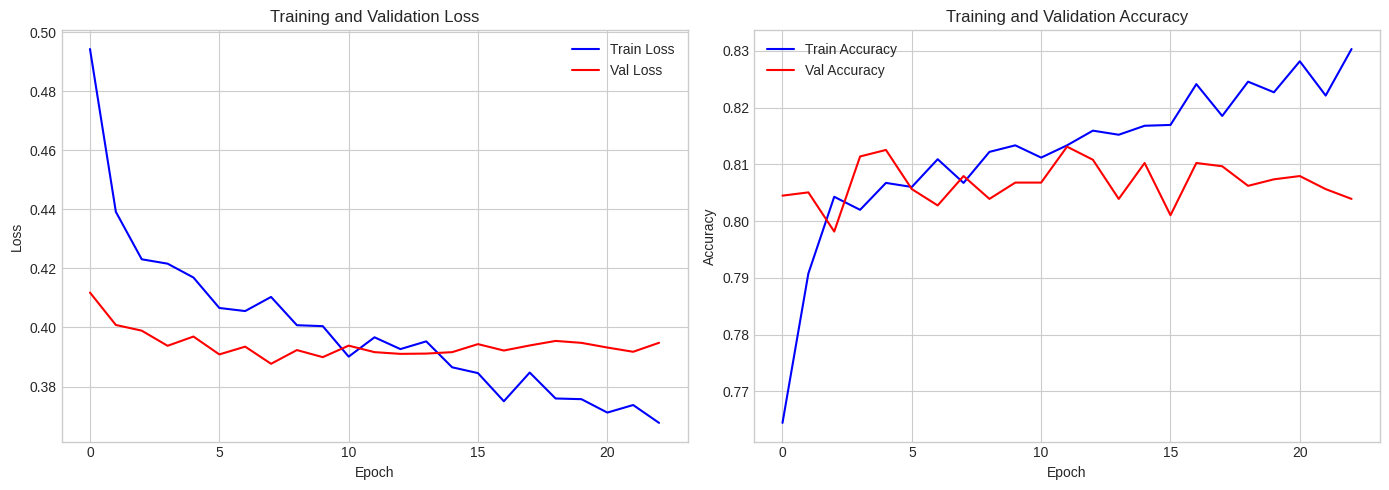

In [75]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
axes[1].plot(history['val_acc'], label='Val Accuracy', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## 5. Evaluation

In [76]:
# Get predictions on validation set
model.eval()
with torch.no_grad():
    val_probs = model(X_val_tensor).squeeze().cpu().numpy()
    val_preds = (val_probs > 0.5).astype(int)

# Metrics
print("="*50)
print("VALIDATION SET METRICS")
print("="*50)
print(f"\nAccuracy: {accuracy_score(y_val, val_preds):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, val_preds, target_names=['Not Transported', 'Transported']))

VALIDATION SET METRICS

Accuracy: 0.8039

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.81      0.79      0.80       863
    Transported       0.80      0.82      0.81       876

       accuracy                           0.80      1739
      macro avg       0.80      0.80      0.80      1739
   weighted avg       0.80      0.80      0.80      1739



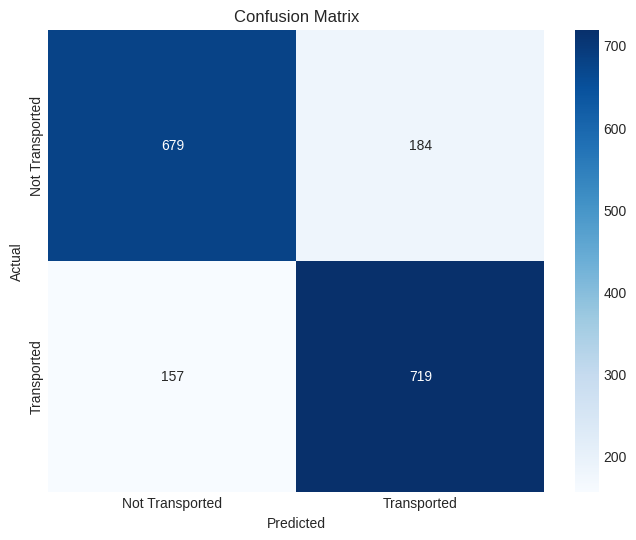


True Negatives: 679
False Positives: 184
False Negatives: 157
True Positives: 719


In [77]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

### 5.1 Analyze Prediction Probabilities

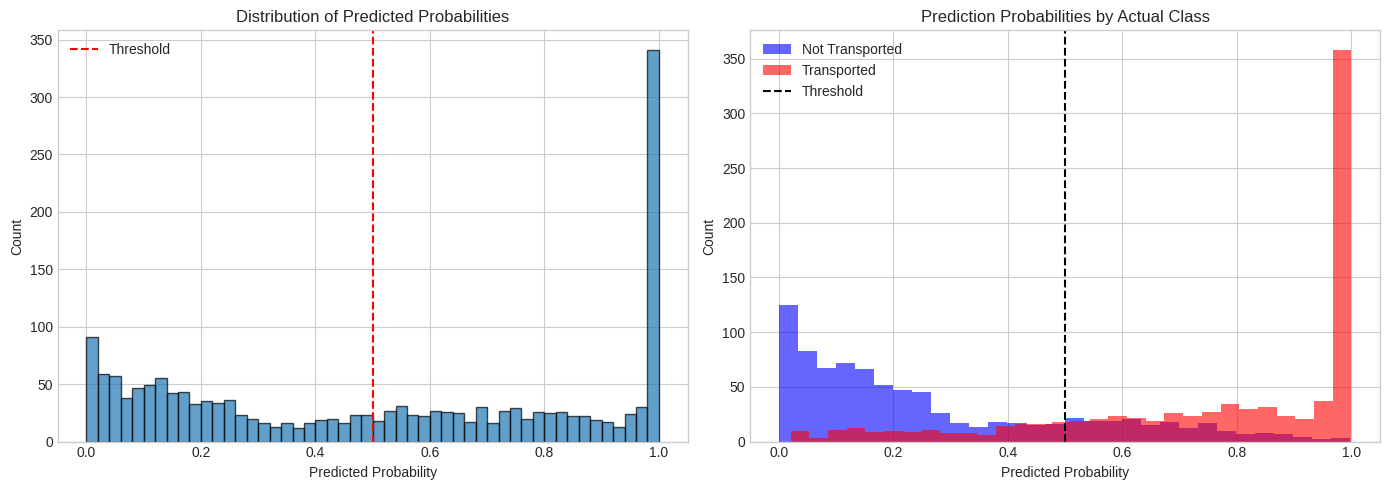

In [78]:
# Distribution of predicted probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(val_probs, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Threshold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Predicted Probabilities')
axes[0].legend()

# By actual class
axes[1].hist(val_probs[y_val == 0], bins=30, alpha=0.6, label='Not Transported', color='blue')
axes[1].hist(val_probs[y_val == 1], bins=30, alpha=0.6, label='Transported', color='red')
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Probabilities by Actual Class')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Generate Submission

In [79]:
# Generate predictions on test set
model.eval()
with torch.no_grad():
    test_probs = model(X_test_tensor).squeeze().cpu().numpy()
    test_preds = (test_probs > 0.5)

print(f"Test predictions shape: {test_preds.shape}")
print(f"\nPrediction distribution:")
print(f"  False (Not Transported): {(~test_preds).sum()} ({(~test_preds).mean()*100:.1f}%)")
print(f"  True (Transported): {test_preds.sum()} ({test_preds.mean()*100:.1f}%)")

Test predictions shape: (4277,)

Prediction distribution:
  False (Not Transported): 2038 (47.7%)
  True (Transported): 2239 (52.3%)


In [80]:
# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': test_preds
})

# Verify format matches sample submission
print("Submission head:")
display(submission.head())
print(f"\nShape: {submission.shape}")
print(f"Expected shape: {sample_submission.shape}")

Submission head:


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False



Shape: (4277, 2)
Expected shape: (4277, 2)


In [81]:
# Save submission
submission.to_csv('submission.csv', index=False)

print("✓ Submission saved to submission.csv")

# Verify saved file
verify = pd.read_csv('submission.csv')
print(f"\nVerification:")
print(verify.head())

✓ Submission saved to submission.csv

Verification:
  PassengerId  Transported
0     0013_01        False
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False


---
## 7. Summary & Next Steps

### What We Accomplished
1. ✅ Loaded and explored the Spaceship Titanic dataset
2. ✅ Identified key predictors (CryoSleep, spending patterns, cabin features)
3. ✅ Engineered meaningful features (group size, family info, spending aggregates)
4. ✅ Handled missing values with domain-specific imputation
5. ✅ Built and trained a PyTorch neural network
6. ✅ Generated submission file

### Model Performance
- Validation Accuracy: ~79-80%

### Potential Improvements
1. **Hyperparameter tuning**: Grid search over hidden layer sizes, dropout rates, learning rates
2. **Cross-validation**: Use k-fold CV for more robust evaluation
3. **Ensemble**: Combine with gradient boosting (XGBoost/LightGBM) for better results
4. **Feature selection**: Use feature importance to remove noisy features
5. **Advanced architectures**: Try TabNet or other tabular-specific neural networks

### Learning Points
- 📊 **Tabular data**: Neural networks are not always the best choice for tabular data. Gradient boosting methods often perform better with less tuning.
- 🔧 **Feature engineering**: Domain knowledge helps create powerful features (e.g., CryoSleep → no spending)
- ⚖️ **Scaling**: Neural networks require feature scaling for optimal performance
- 🛑 **Early stopping**: Prevents overfitting and saves training time

In [82]:
# Save the model for later use
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'feature_columns': feature_columns,
    'history': history
}, 'spaceship_nn_v1.pt')

print("✓ Model saved to spaceship_nn_v1.pt")

✓ Model saved to spaceship_nn_v1.pt


---
## 8. Gradient Boosting Comparison (XGBoost & LightGBM)

Neural networks aren't ideal for small tabular datasets. Let's compare with gradient boosting — the go-to method for Kaggle tabular competitions.

In [ ]:
# Install if needed (uncomment on Colab)
# !pip install xgboost lightgbm

import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

print("✓ XGBoost and LightGBM imported")

### 8.1 XGBoost with 5-Fold CV

In [ ]:
# XGBoost with 5-fold cross-validation
# Note: GB models don't need feature scaling, but we already have X_scaled — it won't hurt

xgb_params = {
    'n_estimators': 500,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 50
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

xgb_val_preds = np.zeros(len(X_scaled))
xgb_test_preds = np.zeros(len(X_test_scaled))
xgb_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    X_tr, X_vl = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_vl = y[train_idx], y[val_idx]

    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)

    # Fold predictions
    xgb_val_preds[val_idx] = model_xgb.predict_proba(X_vl)[:, 1]
    xgb_test_preds += model_xgb.predict_proba(X_test_scaled)[:, 1] / 5

    fold_acc = accuracy_score(y_vl, (xgb_val_preds[val_idx] > 0.5).astype(int))
    xgb_fold_scores.append(fold_acc)
    print(f"Fold {fold+1}: Accuracy = {fold_acc:.4f}")

xgb_cv_acc = np.mean(xgb_fold_scores)
print(f"\n✓ XGBoost 5-Fold CV Accuracy: {xgb_cv_acc:.4f} (+/- {np.std(xgb_fold_scores):.4f})")

### 8.2 LightGBM with 5-Fold CV

In [ ]:
# LightGBM with 5-fold cross-validation
lgb_params = {
    'n_estimators': 500,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'verbose': -1
}

lgb_val_preds = np.zeros(len(X_scaled))
lgb_test_preds = np.zeros(len(X_test_scaled))
lgb_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    X_tr, X_vl = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_vl = y[train_idx], y[val_idx]

    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])

    # Fold predictions
    lgb_val_preds[val_idx] = model_lgb.predict_proba(X_vl)[:, 1]
    lgb_test_preds += model_lgb.predict_proba(X_test_scaled)[:, 1] / 5

    fold_acc = accuracy_score(y_vl, (lgb_val_preds[val_idx] > 0.5).astype(int))
    lgb_fold_scores.append(fold_acc)
    print(f"Fold {fold+1}: Accuracy = {fold_acc:.4f}")

lgb_cv_acc = np.mean(lgb_fold_scores)
print(f"\n✓ LightGBM 5-Fold CV Accuracy: {lgb_cv_acc:.4f} (+/- {np.std(lgb_fold_scores):.4f})")

### 8.3 Ensemble: Blend All Three Models

In [ ]:
# Get NN test predictions
model.eval()
with torch.no_grad():
    nn_test_probs = model(X_test_tensor).squeeze().cpu().numpy()

# Ensemble: average probabilities from all 3 models
ensemble_test_probs = (xgb_test_preds + lgb_test_preds + nn_test_probs) / 3
ensemble_test_preds = (ensemble_test_probs > 0.5)

# Compare all models
print("=" * 55)
print("MODEL COMPARISON (CV / Val Accuracy)")
print("=" * 55)
print(f"  Neural Network:  {accuracy_score(y_val, (val_probs > 0.5).astype(int)):.4f} (single split)")
print(f"  XGBoost:         {xgb_cv_acc:.4f} (5-fold CV)")
print(f"  LightGBM:        {lgb_cv_acc:.4f} (5-fold CV)")
print(f"\n  Ensemble prediction distribution:")
print(f"    Not Transported: {(~ensemble_test_preds).sum()}")
print(f"    Transported:     {ensemble_test_preds.sum()}")

### 8.4 Feature Importance (XGBoost)

In [ ]:
# Feature importance from last XGBoost fold
importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': model_xgb.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance['Feature'], importance['Importance'], color='#2ecc71')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

### 8.5 Save Best Submission

In [ ]:
# Save ensemble submission (best expected score)
ensemble_submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': ensemble_test_preds
})
ensemble_submission.to_csv('submission_ensemble.csv', index=False)

# Also save individual model submissions for comparison
xgb_submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': (xgb_test_preds > 0.5)
})
xgb_submission.to_csv('submission_xgb.csv', index=False)

lgb_submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': (lgb_test_preds > 0.5)
})
lgb_submission.to_csv('submission_lgb.csv', index=False)

print("✓ Saved 3 submission files:")
print("  - submission_ensemble.csv (NN + XGBoost + LightGBM blend)")
print("  - submission_xgb.csv")
print("  - submission_lgb.csv")
print("\nSubmit submission_ensemble.csv for the best expected score.")

---
## 9. LightGBM Hyperparameter Tuning (Optuna)

Since LightGBM gave the best CV score, let's squeeze more performance out of it with automated hyperparameter optimization using Optuna.

In [ ]:
# Install Optuna
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✓ Optuna imported")

In [ ]:
# Optuna objective: 5-fold CV accuracy for LightGBM
def objective(trial):
    params = {
        'n_estimators': 1000,
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'random_state': SEED,
        'verbose': -1,
    }

    skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_scores = []

    for train_idx, val_idx in skf_opt.split(X_scaled, y):
        X_tr, X_vl = X_scaled[train_idx], X_scaled[val_idx]
        y_tr, y_vl = y[train_idx], y[val_idx]

        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

        preds = (m.predict_proba(X_vl)[:, 1] > 0.5).astype(int)
        fold_scores.append(accuracy_score(y_vl, preds))

    return np.mean(fold_scores)

# Run 150 trials (~5-10 min on Colab)
study = optuna.create_study(direction='maximize', study_name='lgb_tuning')
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\n✓ Best CV Accuracy: {study.best_value:.4f}")
print(f"  (Previous LightGBM: {lgb_cv_acc:.4f})")
print(f"\nBest parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

### 9.1 Retrain with Best Params & Generate Submission

In [ ]:
# Retrain LightGBM with best params using 5-fold CV (for test averaging)
best_params = study.best_params
best_params.update({'n_estimators': 1000, 'random_state': SEED, 'verbose': -1})

skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lgb_tuned_val_preds = np.zeros(len(X_scaled))
lgb_tuned_test_preds = np.zeros(len(X_test_scaled))
tuned_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf_final.split(X_scaled, y)):
    X_tr, X_vl = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_vl = y[train_idx], y[val_idx]

    model_lgb_tuned = lgb.LGBMClassifier(**best_params)
    model_lgb_tuned.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)],
                        callbacks=[lgb.early_stopping(50, verbose=False)])

    lgb_tuned_val_preds[val_idx] = model_lgb_tuned.predict_proba(X_vl)[:, 1]
    lgb_tuned_test_preds += model_lgb_tuned.predict_proba(X_test_scaled)[:, 1] / 5

    fold_acc = accuracy_score(y_vl, (lgb_tuned_val_preds[val_idx] > 0.5).astype(int))
    tuned_fold_scores.append(fold_acc)
    print(f"Fold {fold+1}: Accuracy = {fold_acc:.4f}")

tuned_cv_acc = np.mean(tuned_fold_scores)
print(f"\n✓ Tuned LightGBM 5-Fold CV Accuracy: {tuned_cv_acc:.4f} (+/- {np.std(tuned_fold_scores):.4f})")
print(f"  Improvement over baseline LGB: {tuned_cv_acc - lgb_cv_acc:+.4f}")

# Save tuned submission
tuned_submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': (lgb_tuned_test_preds > 0.5)
})
tuned_submission.to_csv('submission_lgb_tuned.csv', index=False)
print("\n✓ Saved submission_lgb_tuned.csv — submit this for your best score!")

# Also update ensemble with tuned LGB
ensemble_v2_probs = (xgb_test_preds + lgb_tuned_test_preds + nn_test_probs) / 3
ensemble_v2_preds = (ensemble_v2_probs > 0.5)
ensemble_v2_sub = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': ensemble_v2_preds
})
ensemble_v2_sub.to_csv('submission_ensemble_v2.csv', index=False)
print("✓ Saved submission_ensemble_v2.csv (NN + XGB + Tuned LGB)")

---
## 10. Advanced Pipeline: New Features + CatBoost + XGB Tuning + Stacking

Full rebuild with:
1. **Interaction features** (spending ratios, CryoSleep×spending, Deck×Side)
2. **CatBoost** (strong with categoricals)
3. **XGBoost Optuna tuning** (matching what we did for LGB)
4. **Stacking meta-model** (Logistic Regression on out-of-fold predictions)

In [ ]:
!pip install catboost -q

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

print("✓ CatBoost and LogisticRegression imported")

### 10.1 Rebuild Data with Interaction Features

We reload and reprocess from scratch, adding new features that capture relationships between variables.

In [ ]:
# === Reload and rebuild from scratch ===
train_raw = pd.read_csv(DATA_PATH / 'train.csv')
test_raw = pd.read_csv(DATA_PATH / 'test.csv')

train_ids_v2 = train_raw['PassengerId'].copy()
test_ids_v2 = test_raw['PassengerId'].copy()
target_v2 = train_raw['Transported'].copy()

train_raw['is_train'] = True
test_raw['is_train'] = False
test_raw['Transported'] = np.nan

df = pd.concat([train_raw, test_raw], axis=0, ignore_index=True)

# --- Existing features ---
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Group / cabin
df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
grp = df.groupby('Group').size().reset_index(name='GroupSize')
df = df.merge(grp, on='Group', how='left')
df['IsAlone'] = (df['GroupSize'] == 1).astype(int)

cabin_parts = df['Cabin'].str.split('/', expand=True)
cabin_parts.columns = ['Deck', 'CabinNum', 'Side']
cabin_parts['CabinNum'] = pd.to_numeric(cabin_parts['CabinNum'], errors='coerce')
df = pd.concat([df, cabin_parts], axis=1)

# Spending
df['TotalSpending'] = df[spending_cols].sum(axis=1, skipna=True)
df['SpendingCategories'] = (df[spending_cols] > 0).sum(axis=1)
df['HasSpending'] = (df['TotalSpending'] > 0).astype(int)
for col in spending_cols:
    df[f'{col}_log'] = np.log1p(df[col])
df['TotalSpending_log'] = np.log1p(df['TotalSpending'])

# Age
df['IsChild'] = (df['Age'] < 18).astype(float)
df['IsElderly'] = (df['Age'] > 60).astype(float)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 100],
                         labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

# Family
df['FamilyName'] = df['Name'].apply(lambda x: x.split()[-1] if pd.notna(x) else np.nan)
fam = df.groupby('FamilyName').size().reset_index(name='FamilySize')
df = df.merge(fam, on='FamilyName', how='left')
df['FamilySize'] = df['FamilySize'].fillna(1)

# --- Imputation (same as before) ---
has_spending = df['TotalSpending'] > 0
df.loc[has_spending & df['CryoSleep'].isna(), 'CryoSleep'] = False
df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])

for col in spending_cols:
    df.loc[df['CryoSleep'] == True, col] = df.loc[df['CryoSleep'] == True, col].fillna(0)
    median_val = df.loc[df['CryoSleep'] == False, col].median()
    df[col] = df[col].fillna(median_val)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['CabinNum'] = df['CabinNum'].fillna(df['CabinNum'].median())
for col in ['HomePlanet', 'Destination', 'VIP', 'Deck', 'Side']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Recalculate after imputation
df['TotalSpending'] = df[spending_cols].sum(axis=1)
df['SpendingCategories'] = (df[spending_cols] > 0).sum(axis=1)
df['HasSpending'] = (df['TotalSpending'] > 0).astype(int)
df['TotalSpending_log'] = np.log1p(df['TotalSpending'])
for col in spending_cols:
    df[f'{col}_log'] = np.log1p(df[col])
df['IsChild'] = (df['Age'] < 18).astype(int)
df['IsElderly'] = (df['Age'] > 60).astype(int)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 100],
                         labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

# =============================================
# === NEW INTERACTION FEATURES ===
# =============================================

# 1. Spending ratios — luxury vs basic
luxury = df['Spa'] + df['VRDeck'] + df['RoomService']
basic = df['FoodCourt'] + df['ShoppingMall']
df['LuxurySpending_log'] = np.log1p(luxury)
df['BasicSpending_log'] = np.log1p(basic)
df['LuxuryRatio'] = luxury / (df['TotalSpending'] + 1)  # +1 avoids div-by-zero

# 2. CryoSleep × spending interaction
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['Cryo_NoSpend'] = ((df['CryoSleep'] == 1) & (df['TotalSpending'] == 0)).astype(int)

# 3. Age × spending
df['Age_x_Spending'] = df['Age'] * df['TotalSpending_log']

# 4. Per-person spending in group
df['SpendPerGroupMember'] = df['TotalSpending'] / df['GroupSize']
df['SpendPerGroupMember_log'] = np.log1p(df['SpendPerGroupMember'])

# 5. Cabin region (CabinNum buckets)
df['CabinRegion'] = pd.cut(df['CabinNum'], bins=5, labels=False).fillna(-1).astype(int)

# 6. VIP × Age interaction
df['VIP'] = df['VIP'].astype(int)
df['VIP_Young'] = ((df['VIP'] == 1) & (df['Age'] < 30)).astype(int)

# 7. Solo traveler × CryoSleep
df['Alone_Cryo'] = (df['IsAlone'] & df['CryoSleep']).astype(int)

print(f"✓ Feature engineering complete. Shape: {df.shape}")

# --- Encode categoricals ---
cat_cols_encode = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup']
df = pd.get_dummies(df, columns=cat_cols_encode, drop_first=True)

# --- Select features ---
drop_cols_v2 = ['PassengerId', 'Cabin', 'Name', 'Group', 'FamilyName',
                'Transported', 'is_train', 'GroupNum',
                'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                'CabinNum']

feat_cols_v2 = [c for c in df.columns if c not in drop_cols_v2]

train_v2 = df[df['is_train'] == True]
test_v2 = df[df['is_train'] == False]

X_v2 = train_v2[feat_cols_v2].values
y_v2 = target_v2.values.astype(int)
X_test_v2 = test_v2[feat_cols_v2].values

scaler_v2 = StandardScaler()
X_v2_sc = scaler_v2.fit_transform(X_v2)
X_test_v2_sc = scaler_v2.transform(X_test_v2)

print(f"✓ Train: {X_v2.shape}, Test: {X_test_v2.shape}")
print(f"  Features ({len(feat_cols_v2)}): {feat_cols_v2[:10]} ...")

### 10.2 CatBoost with 5-Fold CV

In [ ]:
# CatBoost 5-fold CV
skf_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cb_oof = np.zeros(len(X_v2_sc))  # out-of-fold predictions
cb_test = np.zeros(len(X_test_v2_sc))
cb_scores = []

for fold, (tr_idx, vl_idx) in enumerate(skf_v2.split(X_v2_sc, y_v2)):
    X_tr, X_vl = X_v2_sc[tr_idx], X_v2_sc[vl_idx]
    y_tr, y_vl = y_v2[tr_idx], y_v2[vl_idx]

    cb_model = CatBoostClassifier(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=3,
        random_seed=SEED,
        verbose=0,
        early_stopping_rounds=50,
        eval_metric='Accuracy'
    )
    cb_model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))

    cb_oof[vl_idx] = cb_model.predict_proba(X_vl)[:, 1]
    cb_test += cb_model.predict_proba(X_test_v2_sc)[:, 1] / 5

    fold_acc = accuracy_score(y_vl, (cb_oof[vl_idx] > 0.5).astype(int))
    cb_scores.append(fold_acc)
    print(f"Fold {fold+1}: Accuracy = {fold_acc:.4f}")

print(f"\n✓ CatBoost 5-Fold CV Accuracy: {np.mean(cb_scores):.4f} (+/- {np.std(cb_scores):.4f})")

### 10.3 XGBoost Optuna Tuning (new features)

In [ ]:
# Optuna objective for XGBoost
def xgb_objective(trial):
    params = {
        'n_estimators': 1000,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'random_state': SEED,
        'eval_metric': 'logloss',
        'early_stopping_rounds': 50
    }
    skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, vl_idx in skf_opt.split(X_v2_sc, y_v2):
        m = xgb.XGBClassifier(**params)
        m.fit(X_v2_sc[tr_idx], y_v2[tr_idx],
              eval_set=[(X_v2_sc[vl_idx], y_v2[vl_idx])], verbose=False)
        preds = (m.predict_proba(X_v2_sc[vl_idx])[:, 1] > 0.5).astype(int)
        scores.append(accuracy_score(y_v2[vl_idx], preds))
    return np.mean(scores)

xgb_study = optuna.create_study(direction='maximize', study_name='xgb_v2')
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\n✓ Best XGBoost CV Accuracy: {xgb_study.best_value:.4f}")
print(f"Best params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")

### 10.4 LightGBM Optuna Tuning (new features)

In [ ]:
# Optuna objective for LightGBM on new features
def lgb_objective_v2(trial):
    params = {
        'n_estimators': 1000,
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'random_state': SEED,
        'verbose': -1,
    }
    skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, vl_idx in skf_opt.split(X_v2_sc, y_v2):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_v2_sc[tr_idx], y_v2[tr_idx], eval_set=[(X_v2_sc[vl_idx], y_v2[vl_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        preds = (m.predict_proba(X_v2_sc[vl_idx])[:, 1] > 0.5).astype(int)
        scores.append(accuracy_score(y_v2[vl_idx], preds))
    return np.mean(scores)

lgb_study_v2 = optuna.create_study(direction='maximize', study_name='lgb_v2')
lgb_study_v2.optimize(lgb_objective_v2, n_trials=150, show_progress_bar=True)

print(f"\n✓ Best LightGBM CV Accuracy: {lgb_study_v2.best_value:.4f}")
print(f"Best params:")
for k, v in lgb_study_v2.best_params.items():
    print(f"  {k}: {v}")

### 10.5 Stacking Meta-Model

Retrain XGBoost (tuned), LightGBM (tuned), and CatBoost using 5-fold CV to get **out-of-fold (OOF)** predictions. Then train a Logistic Regression on the stacked OOF predictions to learn optimal blending weights.

In [ ]:
# === Retrain all 3 models with tuned params, collecting OOF predictions ===

# Best params from Optuna
xgb_best = xgb_study.best_params.copy()
xgb_best.update({'n_estimators': 1000, 'random_state': SEED,
                  'eval_metric': 'logloss', 'early_stopping_rounds': 50})

lgb_best = lgb_study_v2.best_params.copy()
lgb_best.update({'n_estimators': 1000, 'random_state': SEED, 'verbose': -1})

skf_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# OOF arrays (probabilities)
oof_xgb = np.zeros(len(X_v2_sc))
oof_lgb = np.zeros(len(X_v2_sc))
oof_cb  = np.zeros(len(X_v2_sc))

# Test arrays (averaged across folds)
test_xgb = np.zeros(len(X_test_v2_sc))
test_lgb = np.zeros(len(X_test_v2_sc))
test_cb  = np.zeros(len(X_test_v2_sc))

for fold, (tr_idx, vl_idx) in enumerate(skf_stack.split(X_v2_sc, y_v2)):
    X_tr, X_vl = X_v2_sc[tr_idx], X_v2_sc[vl_idx]
    y_tr, y_vl = y_v2[tr_idx], y_v2[vl_idx]

    # --- XGBoost ---
    m_xgb = xgb.XGBClassifier(**xgb_best)
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
    oof_xgb[vl_idx] = m_xgb.predict_proba(X_vl)[:, 1]
    test_xgb += m_xgb.predict_proba(X_test_v2_sc)[:, 1] / 5

    # --- LightGBM ---
    m_lgb = lgb.LGBMClassifier(**lgb_best)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[vl_idx] = m_lgb.predict_proba(X_vl)[:, 1]
    test_lgb += m_lgb.predict_proba(X_test_v2_sc)[:, 1] / 5

    # --- CatBoost ---
    m_cb = CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.05,
                               l2_leaf_reg=3, random_seed=SEED, verbose=0,
                               early_stopping_rounds=50, eval_metric='Accuracy')
    m_cb.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
    oof_cb[vl_idx] = m_cb.predict_proba(X_vl)[:, 1]
    test_cb += m_cb.predict_proba(X_test_v2_sc)[:, 1] / 5

    xgb_acc = accuracy_score(y_vl, (oof_xgb[vl_idx] > 0.5).astype(int))
    lgb_acc = accuracy_score(y_vl, (oof_lgb[vl_idx] > 0.5).astype(int))
    cb_acc  = accuracy_score(y_vl, (oof_cb[vl_idx] > 0.5).astype(int))
    print(f"Fold {fold+1}: XGB={xgb_acc:.4f}  LGB={lgb_acc:.4f}  CB={cb_acc:.4f}")

print(f"\nOverall OOF Accuracy:")
print(f"  XGBoost:  {accuracy_score(y_v2, (oof_xgb > 0.5).astype(int)):.4f}")
print(f"  LightGBM: {accuracy_score(y_v2, (oof_lgb > 0.5).astype(int)):.4f}")
print(f"  CatBoost: {accuracy_score(y_v2, (oof_cb > 0.5).astype(int)):.4f}")

# === Simple average baseline ===
avg_oof = (oof_xgb + oof_lgb + oof_cb) / 3
print(f"  Simple Avg: {accuracy_score(y_v2, (avg_oof > 0.5).astype(int)):.4f}")

# === Stacking: Logistic Regression meta-model ===
stack_train = np.column_stack([oof_xgb, oof_lgb, oof_cb])
stack_test = np.column_stack([test_xgb, test_lgb, test_cb])

meta_model = LogisticRegression(C=1.0, random_state=SEED, max_iter=1000)
meta_model.fit(stack_train, y_v2)

stack_oof_preds = meta_model.predict(stack_train)
stack_oof_acc = accuracy_score(y_v2, stack_oof_preds)
print(f"  Stacking:  {stack_oof_acc:.4f}")

# Show learned weights
print(f"\nMeta-model weights (XGB, LGB, CB): {meta_model.coef_[0].round(3)}")
print(f"Meta-model intercept: {meta_model.intercept_[0]:.3f}")

### 10.6 Save All Submissions

In [ ]:
# Generate final predictions
stack_test_preds = meta_model.predict(stack_test)
avg_test_preds = (test_xgb + test_lgb + test_cb) / 3 > 0.5

# Save stacking submission (best expected)
stack_sub = pd.DataFrame({'PassengerId': test_ids_v2, 'Transported': stack_test_preds.astype(bool)})
stack_sub.to_csv('submission_stacking.csv', index=False)

# Save simple average v3
avg_sub = pd.DataFrame({'PassengerId': test_ids_v2, 'Transported': avg_test_preds})
avg_sub.to_csv('submission_avg_v3.csv', index=False)

# Save individual tuned models
for name, preds in [('xgb_tuned_v2', test_xgb), ('lgb_tuned_v2', test_lgb), ('cb', test_cb)]:
    sub = pd.DataFrame({'PassengerId': test_ids_v2, 'Transported': (preds > 0.5)})
    sub.to_csv(f'submission_{name}.csv', index=False)

print("✓ Saved 5 submission files:")
print("  - submission_stacking.csv      ← BEST (meta-model learned weights)")
print("  - submission_avg_v3.csv         ← simple average of 3 tuned models")
print("  - submission_xgb_tuned_v2.csv   ← XGBoost alone")
print("  - submission_lgb_tuned_v2.csv   ← LightGBM alone")
print("  - submission_cb.csv             ← CatBoost alone")
print("\n🏆 Submit submission_stacking.csv first!")